In [32]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical,plot_model
from tensorflow.keras.optimizers import Adam
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout,BatchNormalization,Activation
from keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import itertools

In [25]:
# Constants
IMG_SIZE = 48
BATCH_SIZE = 32
TRAIN_DIR = "C:\\Users\\veena\\CloudxLabs\\Kaggle\\Datasets\\FER2013\\train"
VAL_DIR = "C:\\Users\\veena\\CloudxLabs\\Kaggle\\Datasets\\FER2013\\test"
EMOTIONS = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']


In [26]:
for emotion_label, emotion in enumerate(EMOTIONS):
    print(emotion_label,emotion)

0 Angry
1 Disgust
2 Fear
3 Happy
4 Neutral
5 Sad
6 Surprise


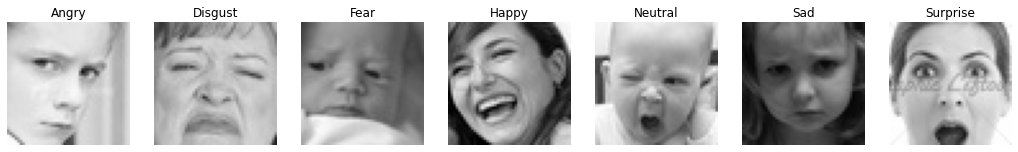

In [27]:
# Function to load images

# Plot the images with each distinct emotions.
plt.figure(figsize=(18,22))
i = 1
for expression in EMOTIONS:
    img = load_img((TRAIN_DIR + '/' + expression +'/'+ os.listdir(TRAIN_DIR + '/' + expression)[59]))
    plt.subplot(1,7,i)
    plt.imshow(img)
    plt.title(expression)
    plt.axis('off')
    i += 1
plt.show()

# Data Preprocessing

In [28]:
# Rescale train data.
datagen_train = ImageDataGenerator(rescale = 1./255,
                                   horizontal_flip=True,
                                   zoom_range=0.3,
                                  )

# Rescale validation data.
datagen_val = ImageDataGenerator(rescale = 1./255,
                                 horizontal_flip=True,
                                 zoom_range=0.3,
                                 )

In [29]:
# Training data.
train_set = datagen_train.flow_from_directory(directory=TRAIN_DIR,
                                              target_size=(IMG_SIZE,IMG_SIZE),
                                              batch_size = BATCH_SIZE,
                                              color_mode = 'grayscale',
                                              class_mode = "categorical",
                                              shuffle=True
                                              )

# Validation data.
val_set = datagen_train.flow_from_directory(directory=VAL_DIR,
                                              target_size=(IMG_SIZE,IMG_SIZE),
                                              batch_size = BATCH_SIZE,
                                              color_mode = 'grayscale',
                                              class_mode = "categorical",
                                              shuffle=False
                                              )

print('Train and Validation sets have been created.')

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Train and Validation sets have been created.


# Model Training

In [30]:
# First layer
model= Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(IMG_SIZE, IMG_SIZE,1)))
model.add(Conv2D(64,(3,3), padding='same', activation='relu' ))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Second layer
model.add(Conv2D(128,(5,5), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Third layer   
model.add(Conv2D(512,(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Fourth layer
model.add(Conv2D(256,(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())

# First fully connected layer
model.add(Dense(256,activation = 'relu'))
model.add(BatchNormalization())
model.add(Dropout(0.30))

# Second fully connected layer  
model.add(Dense(512,activation = 'relu'))
model.add(BatchNormalization())
model.add(Dropout(0.30))

model.add(Dense(7, activation='softmax'))
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_7 (Conv2D)           (None, 48, 48, 32)        320       
                                                                 
 conv2d_8 (Conv2D)           (None, 48, 48, 64)        18496     
                                                                 
 batch_normalization_6 (Batc  (None, 48, 48, 64)       256       
 hNormalization)                                                 
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 24, 24, 64)       0         
 2D)                                                             
                                                                 
 dropout_6 (Dropout)         (None, 24, 24, 64)        0         
                                                                 
 conv2d_9 (Conv2D)           (None, 24, 24, 128)      

In [33]:
model.compile(
    optimizer = Adam(lr=0.001), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
  )

print('CNN model has been created you can proceed to train you data with this model.')

CNN model has been created you can proceed to train you data with this model.


C:\ProgramData\Anaconda3\lib\site-packages\keras\optimizer_v2\adam.py:105: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adam, self).__init__(name, **kwargs)


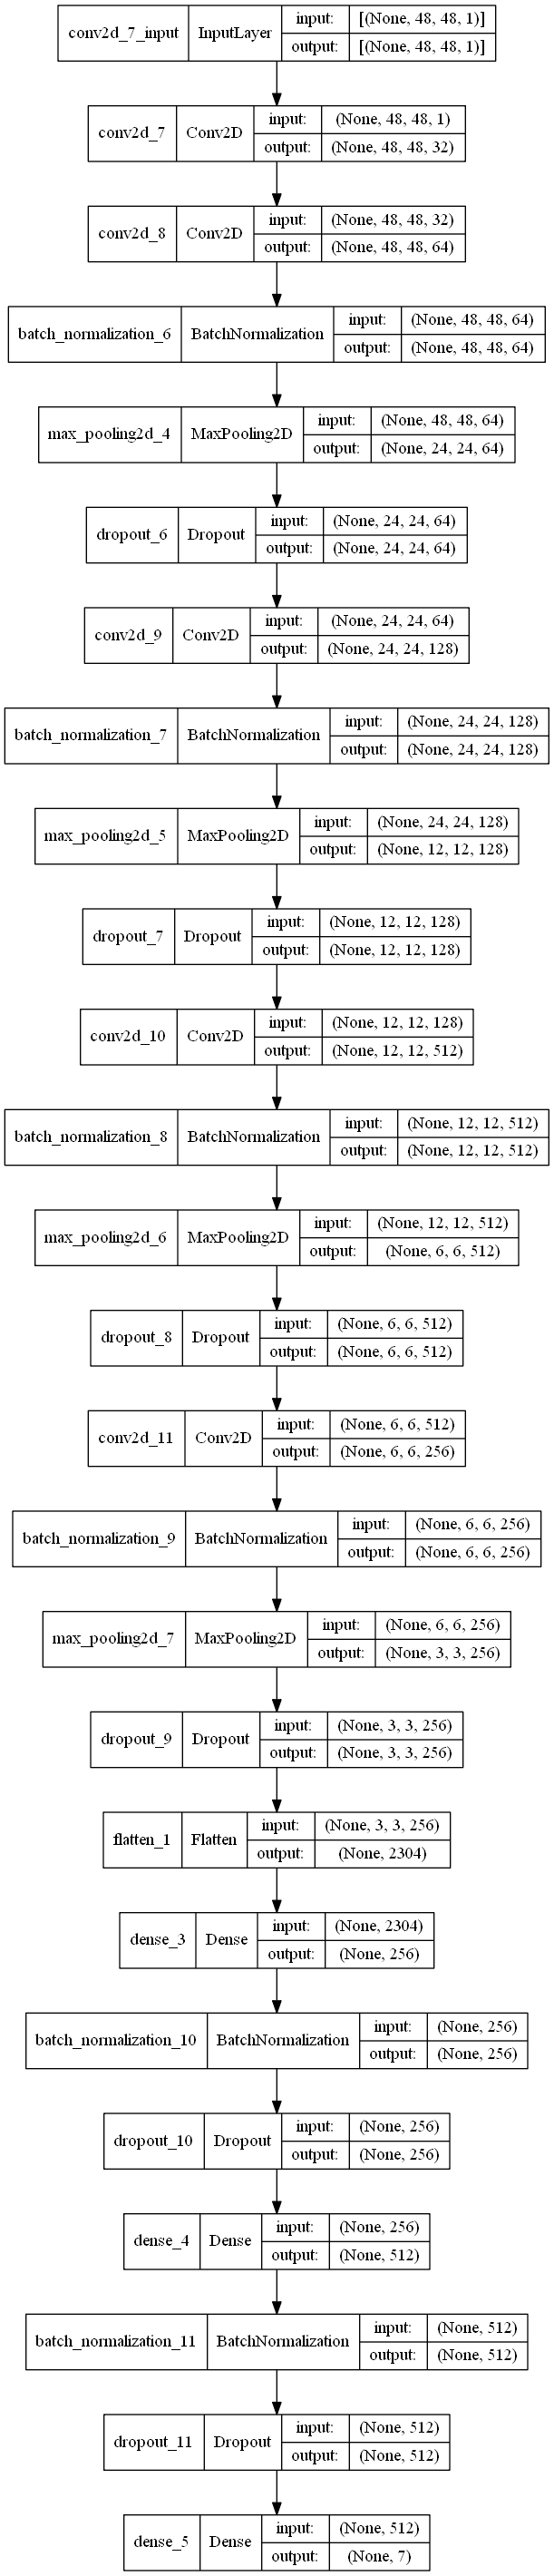

In [34]:
# Visualize the model.
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

In [37]:
# Now lets fit the data to our model.
history = model.fit(train_set,
                              steps_per_epoch=train_set.n//train_set.batch_size,
                              validation_data = val_set,
                              validation_steps=val_set.n//val_set.batch_size,
                              epochs = 20)

print('Your model has been trained!!')

Epoch 1/20
897/897 [==============================] - 470s 525ms/step - loss: 1.9638 - accuracy: 0.2447 - val_loss: 1.7407 - val_accuracy: 0.3004
Epoch 2/20
897/897 [==============================] - 507s 565ms/step - loss: 1.7011 - accuracy: 0.3369 - val_loss: 1.6953 - val_accuracy: 0.3407
Epoch 3/20
897/897 [==============================] - 489s 545ms/step - loss: 1.5174 - accuracy: 0.4106 - val_loss: 1.4076 - val_accuracy: 0.4556
Epoch 4/20
897/897 [==============================] - 488s 544ms/step - loss: 1.3964 - accuracy: 0.4646 - val_loss: 1.2950 - val_accuracy: 0.5053
Epoch 5/20
897/897 [==============================] - 487s 543ms/step - loss: 1.3140 - accuracy: 0.4981 - val_loss: 1.2402 - val_accuracy: 0.5239
Epoch 6/20
897/897 [==============================] - 490s 547ms/step - loss: 1.2622 - accuracy: 0.5228 - val_loss: 1.2300 - val_accuracy: 0.5227
Epoch 7/20
897/897 [==============================] - 486s 542ms/step - loss: 1.2296 - accuracy: 0.5329 - val_loss: 1.2474 -

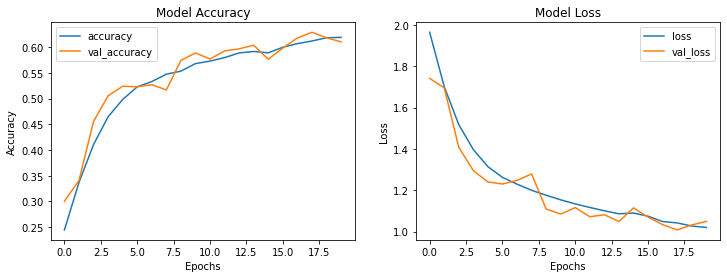

In [38]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

<Figure size 432x288 with 0 Axes>

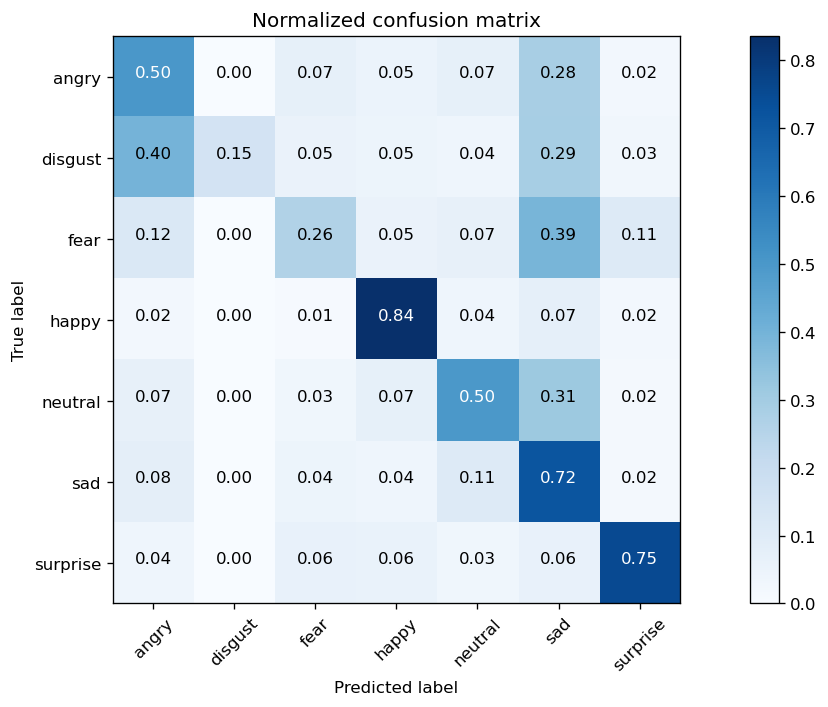

In [40]:
# Create confusion matrix of our predictions

# compute predictions
predictions = model.predict(val_set)
y_pred = [np.argmax(probas) for probas in predictions]
y_test = val_set.classes
class_names = val_set.class_indices.keys()

# Create function to plot confussion matrix.
def plot_confusion_matrix(cm, classes, title='Confusion matrix', cmap=plt.cm.Blues):
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(12,6), dpi=120)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    
    fmt = '.2f'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')# **Live Class Monitoring System(Face Emotion Recognition)**
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()
    
# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

# Plot normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=class_names, title='Normalized confusion matrix')
plt.show()

In [41]:
model.save('model_2.h5')

In [42]:
model.save_weights('model_weights_2.h5')

# Model Evaluation

In [80]:
label_dict = {0:'Angry',1:'Disgust',2:'Fear',3:'Happy',4:'Neutral',5:'Sad',6:'Surprise'}

# Set the path to test image folder
image_folder = "C:\\Users\\veena\\CloudxLabs\\Kaggle\\Datasets\\FER2013\\testImages"

X_test = []
y_test = []

for filename in os.listdir(image_folder):
    if filename.endswith(".jpg"):
        # Full path to the image
        img_path = os.path.join(image_folder, filename)
        
        # Read the image
        img = cv2.imread(img_path)

        # Convert to grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Resize to 48x48
        resized = cv2.resize(gray, (48, 48))

        # Add to the list
        X_test.append(resized)

        # Extract label (part before the underscore)
        label = filename.split("_")[0]
        y_test.append(label)

# Convert to numpy arrays
X_test = np.array(X_test)
y_test = np.array(y_test)

X_test = X_test.reshape(-1, 48, 48, 1)  # Ensure shape is (16, 48, 48, 1)
X_test = X_test.astype("float32") / 255.0  # Normalize pixel values to [0, 1]

# Invert the label_dict
label_to_index = {v: k for k, v in label_dict.items()}

# Convert label names to indices
y_test_indices = np.array([label_to_index[label] for label in y_test])
# One-hot encode
y_test_encoded = to_categorical(y_test_indices, num_classes=len(label_dict))


In [81]:
# Model Evaluation
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_encoded, axis=1)

In [82]:
y_pred_classes

array([4, 3, 4, 5, 4], dtype=int64)

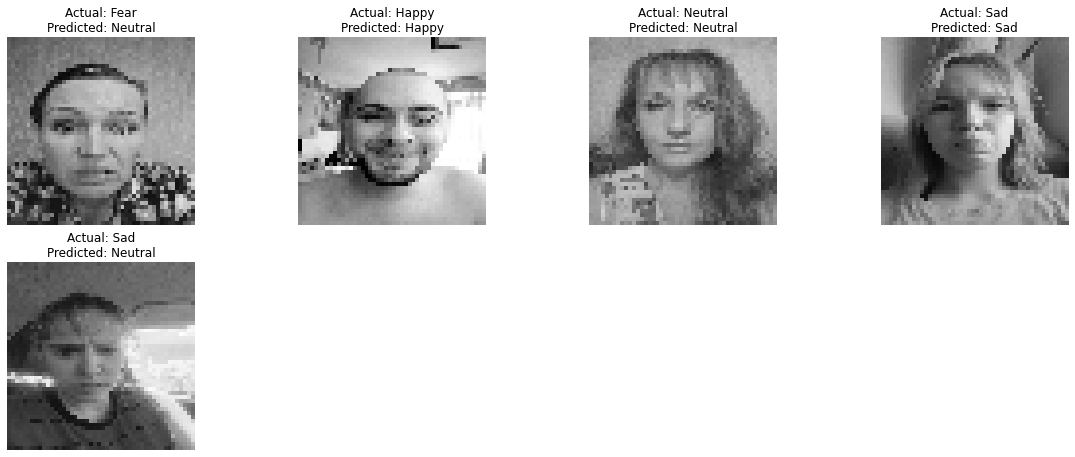

In [83]:
# Display images with predicted and actual labels
num_images = min(20, len(X_test))
plt.figure(figsize=(20, 20))
for i in range(num_images):
    plt.subplot(5, 4, i + 1)
    img = (X_test[i] * 255).astype(np.uint8)  # Convert back to uint8
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for display
    plt.title(f"Actual: {EMOTIONS[y_true[i]]}\nPredicted: {EMOTIONS[y_pred_classes[i]]}")
    plt.axis('off')
plt.show()

(48, 48)


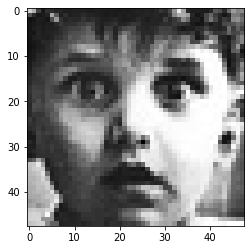

In [78]:
from PIL import Image
img = image.load_img("C:/Users/veena/CloudxLabs/Kaggle/Datasets/FER2013/test/surprise/PrivateTest_2017514.jpg",
                     target_size = (48,48),
                     color_mode = "grayscale")
img = np.array(img)
plt.imshow(img,cmap='gray')
print(img.shape) 
     

In [79]:
img = img.reshape(-1, 48, 48, 1)  # Ensure shape is (no of samples, 48, 48, 1)
img = img.astype("float32") / 255.0  # Normalize pixel values to [0, 1]
y_pred = model.predict(img)
y_pred_class = np.argmax(y_pred, axis=1)
print(label_dict[y_pred_class[0]])
plt.show()

Surprise
